#  10-Year Coronary Heart Disease (CHD) Risk Prediction

## Overview
Cardiovascular disease is a leading cause of death globally, accounting for ~12 million deaths annually. This project uses **machine learning** to predict a patient's **10-year risk of CHD**, supporting early intervention and clinical decision-making.

---

## Evaluation Metrics

| Metric | Purpose |
|---|---|
| **Accuracy** | Overall correct predictions |
| **Confusion Matrix** | Breakdown of TP, TN, FP, FN |
| **Precision** | Minimises false positives |
| **Recall** | Minimises false negatives  |
| **F1 Score** | Balance of precision & recall |
| **AUC-ROC** | Model's class-separation ability (1 = perfect) |

>  **Recall is the priority metric** — missing a high-risk patient is far more critical than a false alarm.

---

## Project Workflow
1. Problem Statement
2. Data Loading & Cleaning
3. Exploratory Data Analysis (EDA)
5. Logistic Regression Model
6. Conclusion

## Problem Statement

Cardiovascular disease remains one of the leading causes of death globally. Early identification 
of high-risk individuals can significantly improve patient outcomes through timely intervention.

This project aims to build a **Logistic Regression model** to predict whether a patient has a 
**10-year risk of developing Coronary Heart Disease (CHD)** based on demographic, behavioural, 
and clinical features from the **Framingham Heart Study** dataset.

The key challenge is the **class imbalance** in the target variable, where high-risk patients 
are significantly underrepresented. Given the medical context, **minimising false negatives 
(missed high-risk patients)** is critical — making **Recall** the primary evaluation metric.

In [1]:
# Import Libraries and Modules

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from collections import Counter
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Data Loading & Cleaning

In [2]:
# Overview of the dataset

df = pd.read_csv("train.csv.xls")
df.head()

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


### Objective
- Predict whether a patient has a 10-year risk of CHD (binary classification)
- Generate meaningful visualizations to uncover key risk factors

### Feature Description of the dataset

***Demographic Variables***
- **Sex**: Male or Female  
- **Age**: Continuous  

***Behavioral Variables***
- **Current Smoker**: Yes/No  
- **Cigarettes Per Day**: Continuous  

***Medical History***
- **BP Medication**: Yes/No  
- **Prevalent Stroke**: Yes/No  
- **Prevalent Hypertension**: Yes/No  
- **Diabetes**: Yes/No  

***Current Medical Measurements***
- **Total Cholesterol**  
- **Systolic Blood Pressure (Sys BP)**  
- **Diastolic Blood Pressure (Dia BP)**  
- **BMI (Body Mass Index)**  
- **Heart Rate**  
- **Glucose Level**  

***Target Variable***
- **10-Year CHD Risk**
  - `1` → High risk  
  - `0` → Low risk  

In [3]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   object 
 4   is_smoking       3390 non-null   object 
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
dtypes: float64(9),

In [4]:
# Check Unique Values.
for i in df.columns.tolist():
  print("No. of unique values in",i,"is",df[i].nunique())

No. of unique values in id is 3390
No. of unique values in age is 39
No. of unique values in education is 4
No. of unique values in sex is 2
No. of unique values in is_smoking is 2
No. of unique values in cigsPerDay is 32
No. of unique values in BPMeds is 2
No. of unique values in prevalentStroke is 2
No. of unique values in prevalentHyp is 2
No. of unique values in diabetes is 2
No. of unique values in totChol is 240
No. of unique values in sysBP is 226
No. of unique values in diaBP is 142
No. of unique values in BMI is 1259
No. of unique values in heartRate is 68
No. of unique values in glucose is 132
No. of unique values in TenYearCHD is 2


In [5]:
df = df.drop("id", axis=1)

In [6]:
# Duplicate Values

duplicate_value_count = len(df[df.duplicated()])
print("The number of duplicate values in the data set is = ",duplicate_value_count)

The number of duplicate values in the data set is =  0


In [7]:
# Mostly we have continuous and categorical(Binary) features except education with Categorical (Ordinal)
# Let's deep dive into education feature:

df[['education', 'TenYearCHD']].corr()

,education,TenYearCHD
education,1.000000,-0.052751
TenYearCHD,-0.052751,1.000000


***Observation:*** Given its near-zero correlation (−0.054) with the target, ambiguous and undocumented encoding, and the risk of injecting noise into an otherwise interpretable logistic regression model, the education column offers no meaningful predictive value and should be dropped.

In [8]:
df = df.drop("education", axis=1)

In [9]:
# Missing Values Count
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent.round(2)
}).reset_index()

missing_df.columns = ['Feature', 'Missing Values', 'Percentage (%)']

missing_df = missing_df[missing_df['Missing Values'] > 0]
print(missing_df.to_string(index=False))

   Feature  Missing Values  Percentage (%)
cigsPerDay              22            0.65
    BPMeds              44            1.30
   totChol              38            1.12
       BMI              14            0.41
 heartRate               1            0.03
   glucose             304            8.97


**Handling Missing Values**

Handling missing data is critical, especially in healthcare datasets where accuracy is essential. Since the records are patient-specific and vary significantly across individuals, simple imputation may introduce incorrect assumptions and affect model reliability.

To address this, a threshold-based approach was used:

- If a feature contains **less than 5% missing values**, the corresponding rows were dropped  
- For features with higher missing values, appropriate imputation techniques were applied cautiously  

This approach helps maintain data quality while minimizing the impact of missing values on model performance.

In [10]:
# features which has less than 5%  null values present. 
nan_columns = ['cigsPerDay', 'BPMeds', 'totChol', 'BMI', 'heartRate']

# dropping null values
df.dropna(subset=nan_columns, inplace=True)

In [11]:
# Glucose levels are continuous in nature.
# Outliers have not been treated yet, so missing values are being imputed using the median.
df['glucose'] = df.glucose.fillna(df.glucose.median())

In [12]:
# checking for null values after treating them.
df.isna().sum()

age                0
sex                0
is_smoking         0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

**Numeric and Categorical Features:**
If feature has more than 2 categories we will consider it as numerical_features, remaining features will be added to categorical_features.

In [13]:
numeric_features = []
categorical_features = []

# Split features into numeric and categorical
for col in df.columns:
    if df[col].nunique() > 2:
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
Categorical Features: ['sex', 'is_smoking', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']


In [14]:
# statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,3272.0,49.442237,8.559199,32.00,42.00,49.00,56.000,70.0
cigsPerDay,3272.0,9.054095,11.866441,0.00,0.00,0.00,20.000,70.0
BPMeds,3272.0,0.029645,0.169633,0.00,0.00,0.00,0.000,1.0
prevalentStroke,3272.0,0.005807,0.075993,0.00,0.00,0.00,0.000,1.0
prevalentHyp,3272.0,0.313264,0.463892,0.00,0.00,0.00,1.000,1.0
diabetes,3272.0,0.025672,0.158180,0.00,0.00,0.00,0.000,1.0
totChol,3272.0,237.036675,45.114324,113.00,206.00,234.00,264.000,696.0
sysBP,3272.0,132.409077,22.123491,83.50,117.00,128.00,143.625,295.0
diaBP,3272.0,82.864456,11.952790,48.00,74.50,82.00,90.000,142.5
BMI,3272.0,25.800339,4.123262,15.96,23.01,25.39,28.040,56.8


***Observation:*** As can be seen in the statistical summary for numerical features, there is a significant difference between the 75% percentile and maximum value, indicating that the dataset contains skewness and outliers.

**Treating Outliers**

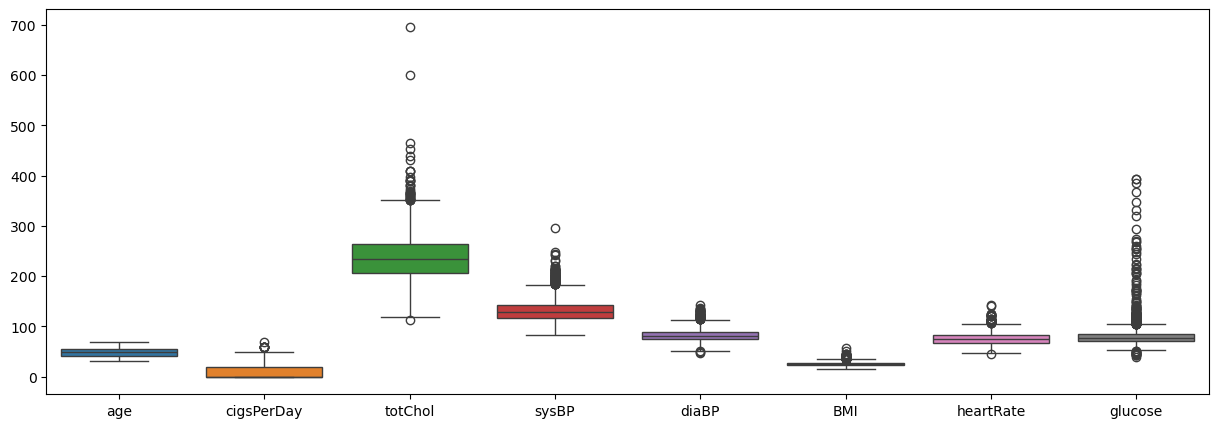

In [15]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df[numeric_features])
plt.show()

**Clipping Method:**

This method limits the impact of outliers by setting upper and lower thresholds. Any values beyond these limits are capped to the nearest boundary value (minimum or maximum), ensuring that extreme values do not distort the data.

In [16]:
def clip_outliers(df):
    for col in df[numeric_features]:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # replacing the outliers with upper and lower bound
        df[col] = df[col].clip(lower_bound, upper_bound)
    return df
df = clip_outliers(df)

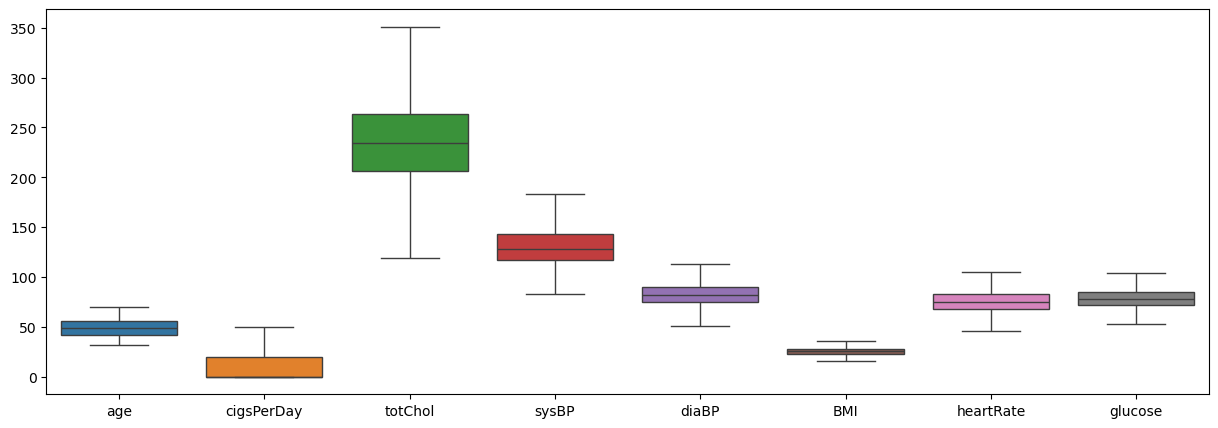

In [17]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df[numeric_features])
plt.show() 

# Exploratory Data Analysis (EDA)

**Let's analyse the categorical features:**

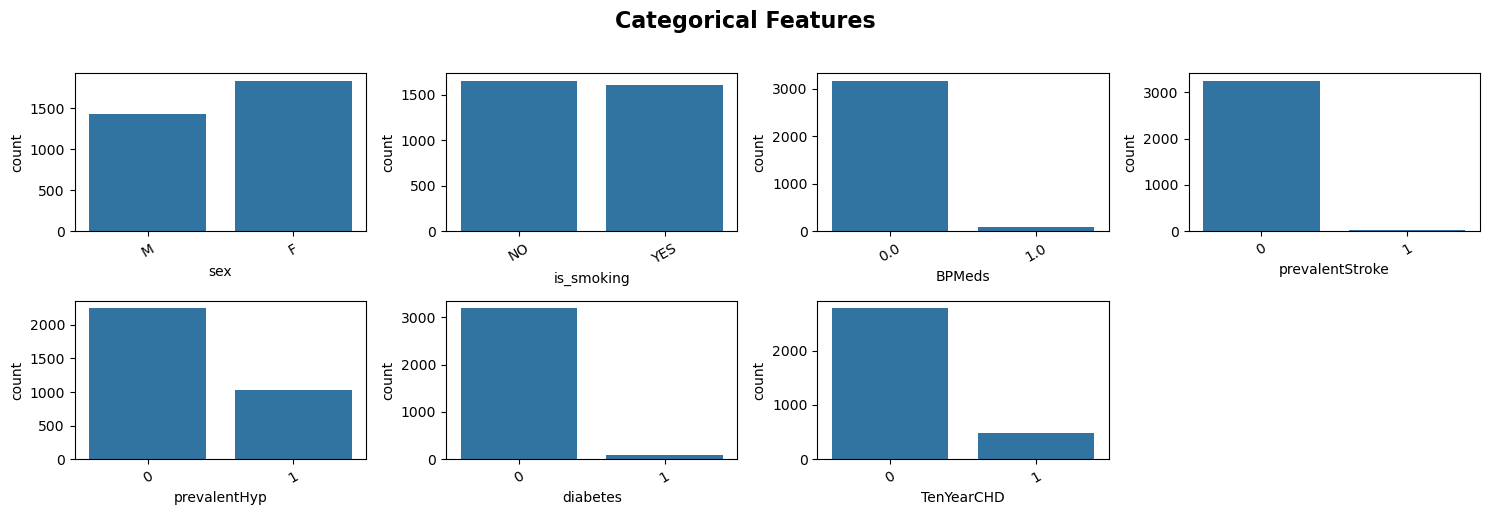

In [18]:
plt.figure(figsize=(15,5))
plt.suptitle('Categorical Features', fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(categorical_features):
    plt.subplot(2, 4, i+1)            
    sns.countplot(x=df[col]) 
    plt.xlabel(col)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Observations

- **Females outnumber males** in the dataset
- **Smokers and non-smokers** are nearly equal in proportion
- Majority are **not on BP medication** and have no history of stroke or hypertension
- **Diabetes cases** are relatively low
- The target variable is **imbalanced**, with fewer patients at risk of CHD but we will address this isssue after spliting the data in train/test for the model to avoid the data leakage

**Let's see the Regression plot between target variable and numerical features:**

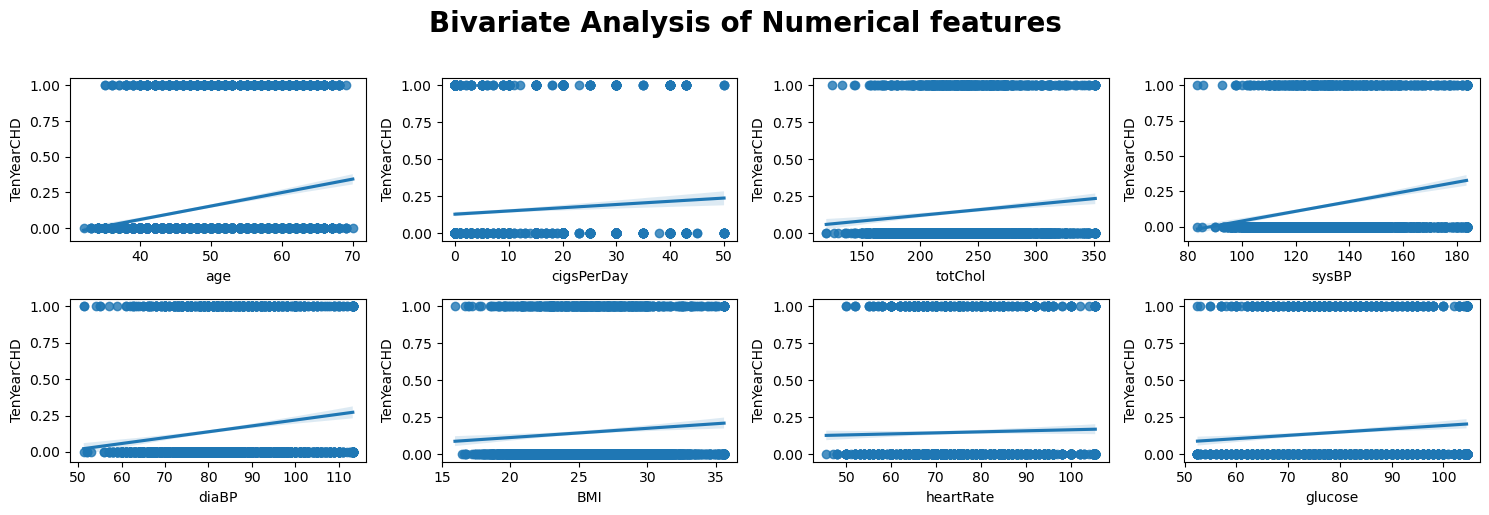

In [19]:
plt.figure(figsize=(15,5))
plt.suptitle('Bivariate Analysis of Numerical features', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(numeric_features):
  plt.subplot(2, 4, i+1)
  sns.regplot(x=df[col], y='TenYearCHD', data=df)
  plt.xlabel(col)
  plt.tight_layout()

## Observations from the Regression Plots

###  Strong Predictors *(steep upward trend)*
- **`age`** — Clear positive trend. Older patients have a noticeably higher CHD risk
- **`sysBP`** — Strong positive trend. Higher systolic blood pressure = higher risk
- **`diaBP`** — Moderate positive trend. Higher diastolic BP links to higher risk

###  Moderate Predictors
- **`cigsPerDay`** — Slight upward trend. More cigarettes = slightly higher risk
- **`glucose`** — Slight positive trend, but most values are clustered low

###  Weak Predictors *(nearly flat line)*
- **`totChol`** — Almost flat. Total cholesterol shows very little relationship with CHD risk
- **`heartRate`** — Nearly flat. Heart rate alone is a poor predictor
- **`BMI`** — Slight positive trend but weak overall

## Feature Engineering

Almost all features in the dataset are already represented numerically (ordinal), 
except for **`sex`** and **`is_smoking`** which contain string categories. 
Therefore, only these two columns require encoding before modelling.

In [20]:
# Label Encoding

df['sex'] = df['sex'].map({'M':1, 'F':0})
df['is_smoking'] = df['is_smoking'].map({'YES':1, 'NO':0})

In [21]:
# dropping our target variable from categorical features list

categorical_features.pop(-1)

'TenYearCHD'

In [22]:
# Cast values in the categorical columns as type string.
df[categorical_features] = df[categorical_features].astype(str)

# checking the result
df.dtypes

age                  int64
sex                 object
is_smoking          object
cigsPerDay         float64
BPMeds              object
prevalentStroke     object
prevalentHyp        object
diabetes            object
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

**Correlation Coefficient and Heatmap**

<Axes: >

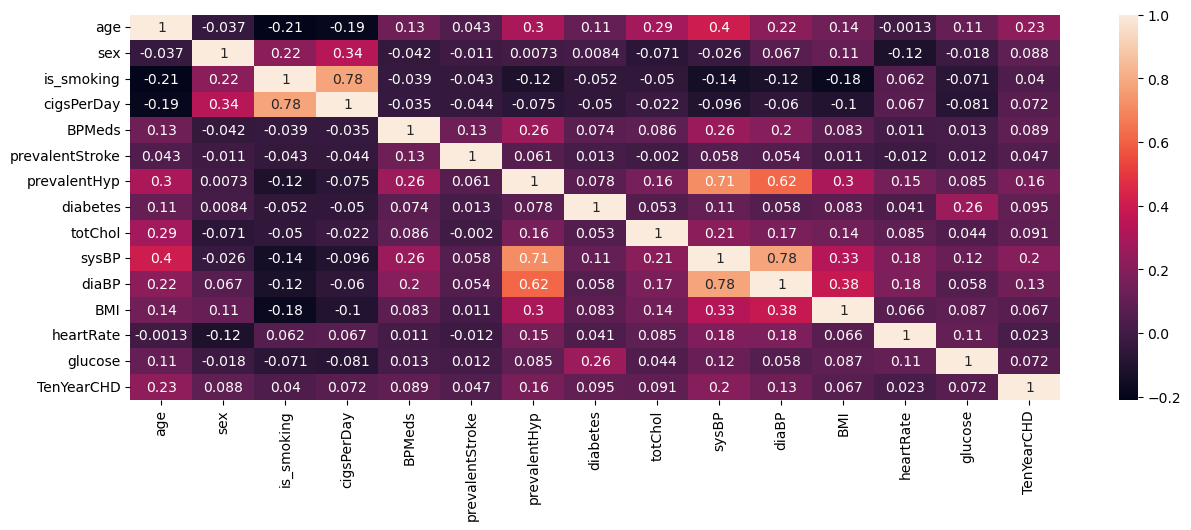

In [23]:
plt.figure(figsize=(15,5))
sns.heatmap(df.corr(), annot=True)

### Strongest Predictors of TenYearCHD
- **age** (0.23) — Highest correlation with CHD risk, confirming older patients are at greater risk
- **sysBP** (0.20) — Higher systolic blood pressure strongly associated with CHD
- **prevalentHyp** (0.16) — Patients with hypertension show higher CHD risk
- **totChol** (0.091) — Weak but positive relationship with CHD

### Weak Predictors of TenYearCHD
- **heartRate** (0.023) — Almost no correlation, confirming it is a poor predictor
- **BMI** (0.067) — Very weak relationship with CHD risk
- **glucose** (0.072) — Slight positive correlation despite diabetes being a known risk factor

### Multicollinearity Concerns
- **sysBP & diaBP** (0.78) — Highly correlated with each other, may cause redundancy
- **sysBP & prevalentHyp** (0.71) — Expected, as hypertension directly affects blood pressure
- **is_smoking & cigsPerDay** (0.78) — Heavily correlated, both measure smoking behaviour
- **diaBP & prevalentHyp** (0.62) — Strong correlation between diastolic BP and hypertension

> High multicollinearity between sysBP/diaBP and is_smoking/cigsPerDay could affect 
> logistic regression coefficient estimates. This was addressed by engineering a new 
> **pulse_pressure** feature (sysBP − diaBP) and dropping both original BP columns.


**Feature Manipulation**

## Feature Engineering — Pulse Pressure

Blood pressure is recorded as two values:
- **Systolic BP (sysBP)** — pressure when the heart beats (higher value)
- **Diastolic BP (diaBP)** — pressure when the heart rests (lower value)

A new feature **pulse_pressure** is derived as:

> **Pulse Pressure = Systolic BP − Diastolic BP**

For example, a reading of 120/80 mm Hg gives a pulse pressure of **40 mm Hg** (normal range).
Values above this threshold indicate **increased cardiovascular risk**, particularly in older individuals.

This feature captures cardiovascular stress more directly than either BP value alone, 
and also resolves the **multicollinearity** between sysBP and diaBP (r = 0.78).

In [24]:
df['pulse_pressure'] = df['sysBP'] - df['diaBP']
df.drop(columns=['sysBP', 'diaBP'], inplace=True)

## Data Consistency Check

A potential inconsistency exists when a patient is marked as a 
**smoker (`is_smoking = "Yes"`)** but has **`cigsPerDay = 0`** — 
which is a contradictory combination.

Such records are identified and removed to maintain **data quality 
and model reliability**, as keeping them could introduce misleading 
patterns during model training.

In [25]:
df[(df.is_smoking == 'YES') & (df.cigsPerDay == 0)]

,age,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,BMI,heartRate,glucose,TenYearCHD,pulse_pressure


Since no conflicting cases were found between is_smoking and cigsPerDay, the smoking information is consistent. Therefore, the cigsPerDay feature alone is sufficient to represent smoking behavior, making is_smoking redundant.

**Dependent and Independent Variable Assignment**

In [26]:
# copying the data to save the work done till now
model_df = df.copy()
model_df.head()

,age,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,BMI,heartRate,glucose,TenYearCHD,pulse_pressure
1,36,1,0,0.0,0.0,0,1,0,212.0,29.77,72.0,75.0,0,70.00
2,46,0,1,10.0,0.0,0,0,0,250.0,20.35,88.0,94.0,0,45.00
3,50,1,1,20.0,0.0,0,1,0,233.0,28.26,68.0,94.0,1,70.00
4,64,0,1,30.0,0.0,0,0,0,241.0,26.42,70.0,77.0,0,51.50
5,61,0,0,0.0,0.0,0,1,0,272.0,32.80,85.0,65.0,1,68.75


In [27]:
X = model_df.drop(columns='TenYearCHD')     # independent features
y = model_df['TenYearCHD']                  # dependent features

# Logistic Regression Model

In [28]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(X_train.shape)
print(X_test.shape)

(2617, 13)
(655, 13)


In [29]:
# Scaling Data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
# To handle the imbalance in the target variable we use SMOTE (Synthetic Minority Oversampling Technique).

# Check class balance after SMOTE
print("Before SMOTE:", Counter(y_train))
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_train))

Before SMOTE: Counter({0: 2232, 1: 385})
After SMOTE: Counter({0: 2232, 1: 2232})


Logistic Regression Performance
--------------------------------------------------
Train Accuracy : 0.679
Test Accuracy  : 0.641
Train Precision: 0.679
Test Precision : 0.248
Train Recall   : 0.680
Test Recall    : 0.631
Train F1 Score : 0.679
Test F1 Score  : 0.356
Train ROC-AUC  : 0.749
Test ROC-AUC   : 0.643
--------------------------------------------------
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.90      0.64      0.75       552
           1       0.25      0.63      0.36       103

    accuracy                           0.64       655
   macro avg       0.58      0.64      0.55       655
weighted avg       0.80      0.64      0.69       655



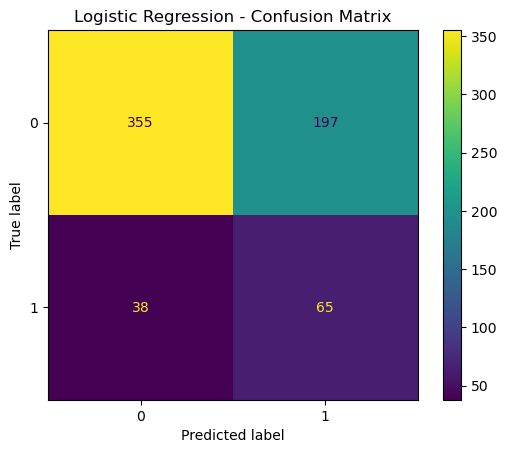

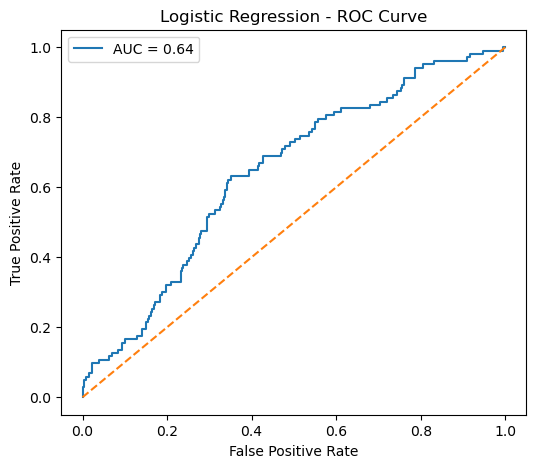

In [31]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

y_train_prob = lr_model.predict_proba(X_train)[:, 1]
y_test_prob = lr_model.predict_proba(X_test)[:, 1]


# ---------------- Performance Metrics ---------------- #

print("Logistic Regression Performance")
print("-" * 50)

print(f"Train Accuracy : {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Test Accuracy  : {accuracy_score(y_test, y_test_pred):.3f}")

print(f"Train Precision: {precision_score(y_train, y_train_pred):.3f}")
print(f"Test Precision : {precision_score(y_test, y_test_pred):.3f}")

print(f"Train Recall   : {recall_score(y_train, y_train_pred):.3f}")
print(f"Test Recall    : {recall_score(y_test, y_test_pred):.3f}")

print(f"Train F1 Score : {f1_score(y_train, y_train_pred):.3f}")
print(f"Test F1 Score  : {f1_score(y_test, y_test_pred):.3f}")

print(f"Train ROC-AUC  : {roc_auc_score(y_train, y_train_prob):.3f}")
print(f"Test ROC-AUC   : {roc_auc_score(y_test, y_test_prob):.3f}")

print("-" * 50)


# ---------------- Classification Report ---------------- #
print("Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))


# ---------------- Confusion Matrix ---------------- #
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.title('Logistic Regression - Confusion Matrix')
plt.show()


# ---------------- ROC Curve ---------------- #
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_test_prob):.2f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression - ROC Curve')
plt.legend()
plt.show()

**Coefficients**

            Feature  Coefficient  Odds Ratio
0               age     0.804574    2.235744
1        cigsPerDay     0.281962    1.325729
2               sex     0.197342    1.218161
3    pulse_pressure     0.138308    1.148329
4          diabetes     0.130649    1.139568
5      prevalentHyp     0.117881    1.125110
6           totChol     0.101595    1.106935
7   prevalentStroke     0.074803    1.077672
8        is_smoking     0.057898    1.059607
9            BPMeds     0.053434    1.054888
10          glucose     0.053219    1.054661
11              BMI    -0.035325    0.965291
12        heartRate    -0.074334    0.928362


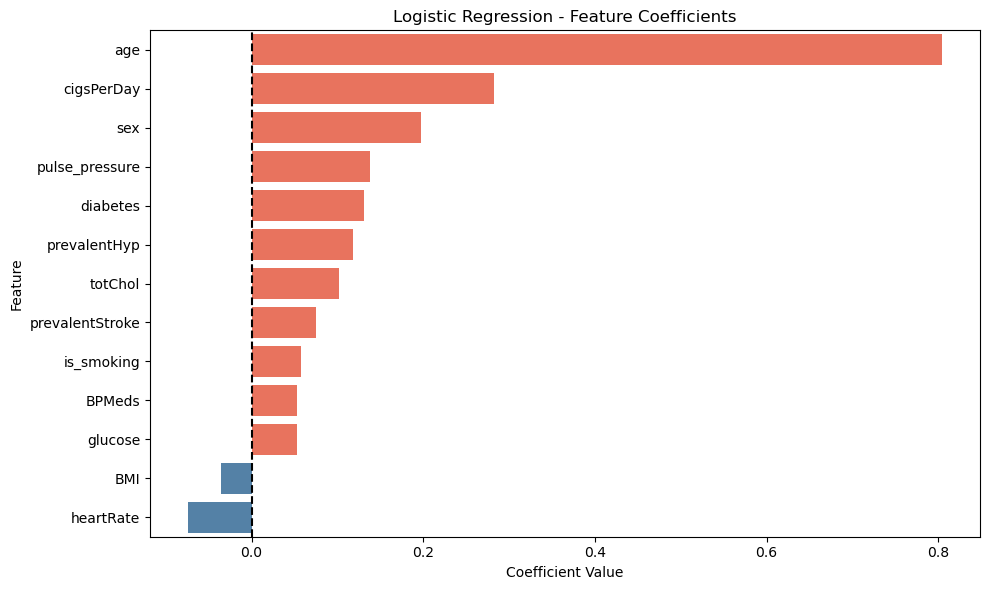

In [32]:
# ---------------- Model Coefficients ---------------- #
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

coefficients['Odds Ratio'] = np.exp(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Coefficient', ascending=False).reset_index(drop=True)
print(coefficients)

# ---------------- Coefficient Plot ---------------- #
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients,
            palette=['tomato' if c > 0 else 'steelblue' for c in coefficients['Coefficient']])
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Logistic Regression - Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

> Features with **positive coefficients** increase CHD risk, while **negative coefficients** 
> slightly reduce predicted risk. Since data was scaled, coefficients are directly comparable.

## Conclusion

The Logistic Regression model was trained to predict the 10-year risk of Coronary Heart 
Disease (CHD) using the Framingham Heart Study dataset.

### Model Performance Summary

| Metric | Train | Test |
|---|---|---|
| Accuracy | 0.679 | 0.641 |
| Precision | 0.679 | 0.248 |
| Recall | 0.680 | 0.631 |
| F1 Score | 0.679 | 0.356 |
| ROC-AUC | 0.749 | 0.643 |

### Key Findings

- **`age`** was the strongest predictor (Odds Ratio: 2.24) — the risk of CHD increases 
  significantly with every additional year of age
- **`cigsPerDay`** (OR: 1.33) and **`sex`** (OR: 1.22) were the next most influential, 
  confirming smoking behaviour and gender as notable risk factors
- **`diabetes`**, **`prevalentHyp`**, and **`pulse_pressure`** contributed moderate 
  predictive signal, aligning with known clinical risk factors
- **`BMI`** and **`heartRate`** showed near-zero coefficients, contributing 
  the least predictive power to the model
- **Recall of 0.631** — the model correctly identifies 63% of true high-risk patients, 
  satisfying our primary objective in a healthcare context
- **ROC-AUC of 0.643** reflects moderate class separation ability
- The **Train/Test F1 gap (0.679 vs 0.356)** indicates mild overfitting, 
  likely due to class imbalance in the test set

### Final Remarks

Since missing a high-risk patient carries far greater consequences than a false alarm, 
**Recall was prioritised** as the key evaluation metric throughout this project.
The model demonstrates moderate but clinically meaningful performance, with **age, 
smoking, and gender** emerging as the most actionable risk factors. Future work could 
explore **ensemble models**, **hyperparameter tuning**, or **threshold optimisation** 
to further improve the identification of high-risk patients.